# Final Model Evaluation Summary

Consolidated evaluation plots and headline metrics for the **selected final model** — Exp-6 (uncertainty weighting) with isotonic probability calibration — on the held-out test set. Earlier notebooks plotted ROC/scatter for the Exp-1/Exp-2 single-task *baselines* (`04`) and reliability diagrams for Exp-6 (`06`); this notebook produces the equivalent ROC/PR/LTV-scatter plots for the actual model being shipped, so there's one place with the complete picture (Section 9.2's "Evaluation Plots" deliverable).

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    average_precision_score, precision_recall_curve, r2_score, roc_auc_score, roc_curve,
)
from torch.utils.data import DataLoader, Dataset

PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
MODELS_DIR = os.path.join(os.getcwd(), "models")
RESULTS_DIR = os.path.join(os.getcwd(), "results")

with open(os.path.join(PROCESSED_DIR, "feature_manifest.json")) as f:
    manifest = json.load(f)

CAT_COLS = [v["column"] for v in manifest["categorical"].values()]
NUM_COLS = manifest["numerical_scaled"] + manifest["numerical_unscaled"]
CARDINALITIES = {v["column"]: v["cardinality"] for v in manifest["categorical"].values()}
EMBED_DIMS = {v["column"]: v["embedding_dim"] for v in manifest["categorical"].values()}

In [2]:
class KKBoxDataset(Dataset):
    def __init__(self, df):
        self.x_cat = torch.tensor(df[CAT_COLS].values, dtype=torch.long)
        self.x_num = torch.tensor(df[NUM_COLS].values, dtype=torch.float32)
        self.y_churn = torch.tensor(df["is_churn"].values, dtype=torch.float32)
        self.y_ltv = torch.tensor(df["log1p_ltv"].values, dtype=torch.float32)

    def __len__(self):
        return len(self.y_churn)

    def __getitem__(self, idx):
        return self.x_num[idx], self.x_cat[idx], self.y_churn[idx], self.y_ltv[idx]


class FMInteractionLayer(nn.Module):
    def __init__(self, input_dim, k=8):
        super().__init__()
        self.V = nn.Parameter(torch.randn(input_dim, k) * 0.01)

    def forward(self, x):
        xV = x.unsqueeze(2) * self.V.unsqueeze(0)
        sum_then_sq = xV.sum(dim=1).pow(2)
        sq_then_sum = xV.pow(2).sum(dim=1)
        return 0.5 * (sum_then_sq - sq_then_sum)


class MultiTaskFMNet(nn.Module):
    def __init__(self, cat_cols, cardinalities, embed_dims, num_numerical, fm_k=8, backbone_dims=(256, 128, 64)):
        super().__init__()
        self.cat_cols = cat_cols
        self.embeddings = nn.ModuleDict(
            {col: nn.Embedding(cardinalities[col], embed_dims[col]) for col in cat_cols}
        )
        combined_dim = sum(embed_dims[c] for c in cat_cols) + num_numerical
        self.fm = FMInteractionLayer(combined_dim, k=fm_k)
        backbone_input = combined_dim + fm_k
        layers, prev = [], backbone_input
        for dim, p in zip(backbone_dims, [0.3, 0.3, 0.2]):
            layers += [nn.Linear(prev, dim), nn.BatchNorm1d(dim), nn.ReLU(), nn.Dropout(p)]
            prev = dim
        self.backbone = nn.Sequential(*layers)
        self.churn_head = nn.Sequential(nn.Linear(prev, 32), nn.ReLU(), nn.Linear(32, 1))
        self.ltv_head = nn.Sequential(nn.Linear(prev, 32), nn.ReLU(), nn.Linear(32, 1))

    def forward(self, x_num, x_cat):
        embeds = [self.embeddings[col](x_cat[:, i]) for i, col in enumerate(self.cat_cols)]
        x = torch.cat(embeds + [x_num], dim=1)
        fm_out = self.fm(x)
        h = torch.cat([x, fm_out], dim=1)
        shared = self.backbone(h)
        return self.churn_head(shared).squeeze(-1), self.ltv_head(shared).squeeze(-1)


val_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_val.parquet"))
test_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_test.parquet"))
val_loader = DataLoader(KKBoxDataset(val_df), batch_size=2048, shuffle=False)
test_loader = DataLoader(KKBoxDataset(test_df), batch_size=2048, shuffle=False)

model = MultiTaskFMNet(CAT_COLS, CARDINALITIES, EMBED_DIMS, len(NUM_COLS))
ckpt = torch.load(os.path.join(MODELS_DIR, "exp6_uncertainty.pt"), weights_only=True)
model.load_state_dict(ckpt["model"])
model.eval()


def get_predictions(loader):
    all_churn_logit, all_churn_true, all_ltv_pred, all_ltv_true = [], [], [], []
    with torch.no_grad():
        for x_num, x_cat, y_churn, y_ltv in loader:
            churn_logit, ltv_pred = model(x_num, x_cat)
            all_churn_logit.append(churn_logit)
            all_churn_true.append(y_churn)
            all_ltv_pred.append(ltv_pred)
            all_ltv_true.append(y_ltv)
    return (torch.cat(all_churn_logit), torch.cat(all_churn_true),
            torch.cat(all_ltv_pred), torch.cat(all_ltv_true))


val_logit, val_churn_true, val_ltv_pred, val_ltv_true = get_predictions(val_loader)
test_logit, test_churn_true, test_ltv_pred, test_ltv_true = get_predictions(test_loader)

iso_reg = IsotonicRegression(out_of_bounds="clip")
iso_reg.fit(torch.sigmoid(val_logit).numpy(), val_churn_true.numpy())
test_p_churn = iso_reg.predict(torch.sigmoid(test_logit).numpy())
test_churn_true_np = test_churn_true.numpy()
test_ltv_pred_raw = np.expm1(test_ltv_pred.numpy())
test_ltv_true_raw = np.expm1(test_ltv_true.numpy())

## Headline metrics (test set, calibrated probabilities)

In [3]:
auc_roc = roc_auc_score(test_churn_true_np, test_p_churn)
auc_pr = average_precision_score(test_churn_true_np, test_p_churn)
rmse_raw = float(np.sqrt(np.mean((test_ltv_pred_raw - test_ltv_true_raw) ** 2)))
mae_raw = float(np.mean(np.abs(test_ltv_pred_raw - test_ltv_true_raw)))
r2_raw = float(r2_score(test_ltv_true_raw, test_ltv_pred_raw))

final_metrics = {
    "model": "exp6_uncertainty_isotonic_calibrated",
    "churn_auc_roc": auc_roc,
    "churn_auc_pr": auc_pr,
    "ltv_rmse_raw_twd": rmse_raw,
    "ltv_mae_raw_twd": mae_raw,
    "ltv_r2_raw": r2_raw,
}
with open(os.path.join(RESULTS_DIR, "final_model_metrics.json"), "w") as f:
    json.dump(final_metrics, f, indent=2)
final_metrics

{'model': 'exp6_uncertainty_isotonic_calibrated',
 'churn_auc_roc': 0.9321083840047075,
 'churn_auc_pr': 0.971435994683752,
 'ltv_rmse_raw_twd': 153.7383575439453,
 'ltv_mae_raw_twd': 67.52839660644531,
 'ltv_r2_raw': 0.09884721040725708}

## Consolidated evaluation plots

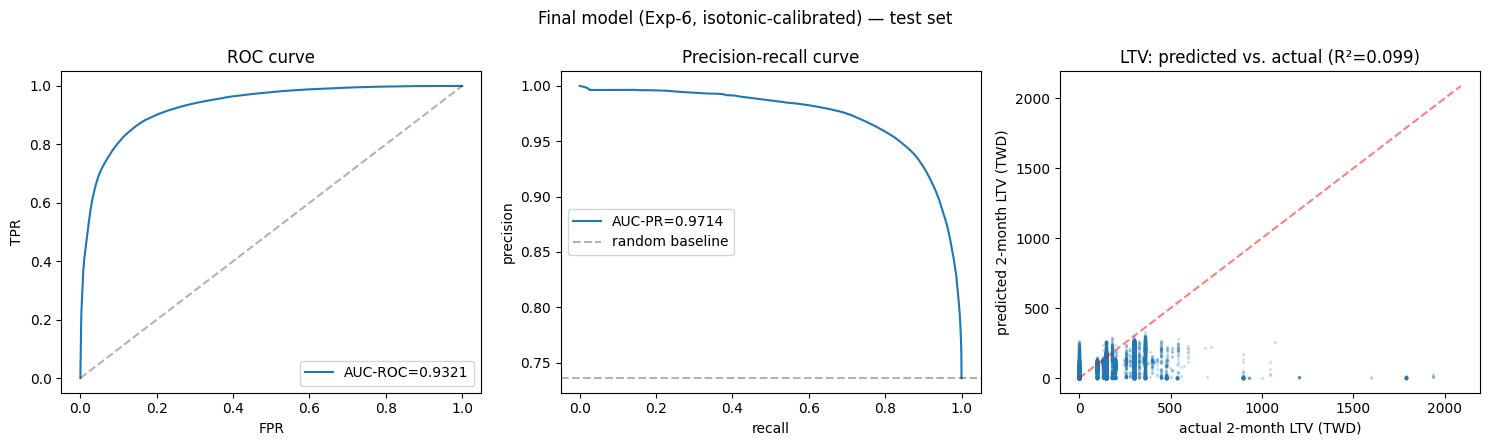

In [4]:
fpr, tpr, _ = roc_curve(test_churn_true_np, test_p_churn)
precision, recall, _ = precision_recall_curve(test_churn_true_np, test_p_churn)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(fpr, tpr, label=f"AUC-ROC={auc_roc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("ROC curve")
axes[0].legend()

axes[1].plot(recall, precision, label=f"AUC-PR={auc_pr:.4f}")
axes[1].axhline(test_churn_true_np.mean(), color="k", linestyle="--", alpha=0.3, label="random baseline")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("Precision-recall curve")
axes[1].legend()

sample = np.random.default_rng(42).choice(len(test_ltv_pred_raw), size=20000, replace=False)
axes[2].scatter(test_ltv_true_raw[sample], test_ltv_pred_raw[sample], s=2, alpha=0.15)
lims = [0, max(test_ltv_true_raw.max(), test_ltv_pred_raw.max())]
axes[2].plot(lims, lims, "r--", alpha=0.5)
axes[2].set_xlabel("actual 2-month LTV (TWD)")
axes[2].set_ylabel("predicted 2-month LTV (TWD)")
axes[2].set_title(f"LTV: predicted vs. actual (R²={r2_raw:.3f})")

fig.suptitle("Final model (Exp-6, isotonic-calibrated) — test set")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "final_model_evaluation.png"), dpi=120)